In [1]:
!pip install torch-geometric -q
!pip install torch-scatter torch-sparse -q
!pip install imbalanced-learn xgboost lightgbm -q
!pip install reportlab -q
print("✅ All packages installed!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 60.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 7.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.0/210.0 kB 18.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 73.0 MB/s eta 0:00:00
✅ All packages installed!


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import io

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.nn import GATv2Conv, SAGEConv, BatchNorm

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import kneighbors_graph
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score,
    f1_score, confusion_matrix, roc_curve, precision_recall_curve,
    precision_score, recall_score
)
from sklearn.manifold import TSNE

from imblearn.over_sampling import SMOTE
from collections import Counter

import xgboost as xgb

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Imports done | Device: {device}")

Imports done | Device: cpu


In [3]:
import pandas as pd
import io

# Load the dataset directly (update path if needed)
df = pd.read_csv('eth_illicit_features.csv')

df.columns = df.columns.str.strip()

# Use the 'flag' column (lowercase) as the target
if 'flag' in df.columns:
    df['FLAG'] = df['flag'].astype(int)
    df.drop(columns=['flag'], inplace=True)
    print("Using 'flag' column renamed to 'FLAG'.")
elif 'FLAG' in df.columns:
    df['FLAG'] = df['FLAG'].astype(int)
    print("Using existing 'FLAG' column.")
else:
    print("Warning: No FLAG/flag column found. Setting FLAG=0.")
    df['FLAG'] = 0

print(f"Shape      : {df.shape}")
print(f"Fraud Rate : {df['FLAG'].mean()*100:.1f}%")
print(f"\nClass Distribution:\n{df['FLAG'].value_counts()}")
df.head(3)

Using 'flag' column renamed to 'FLAG'.
Shape      : (12146, 34)
Fraud Rate : 42.4%

Class Distribution:
FLAG
0    6996
1    5150
Name: count, dtype: int64


,address,minTimeBetweenSentTnx,maxTimeBetweenSentTnx,avgTimeBetweenSentTnx,minTimeBetweenRecTnx,maxTimeBetweenRecTnx,avgTimeBetweenRecTnx,lifetime,sentTransactions,receivedTransactions,...,activityDays,dailyMax,ratioRecSent,ratioSentTotal,ratioRecTotal,giniSent,giniRec,txFreq,stdBalanceEth,FLAG
0,0xd0cc2b24980cbcca47ef755da88b220a82291407,0.0,2387389.0,5.807655e+04,89.0,1.501076e+09,7.148260e+07,46,66,21,...,10,60,0.313433,0.750000,0.238636,0.969121,0.888782,1.891304,147.701484,1
1,0x4cdc1cba0aeb5539f2e0ba158281e67e0e54a9b1,0.0,0.0,0.000000e+00,3021091.0,1.502802e+09,7.529115e+08,35,0,2,...,2,1,2.000000,0.000000,0.666667,0.000000,0.238480,0.057143,0.005000,1
2,0x00e01a648ff41346cdeb873182383333d2184dd1,37.0,25112882.0,1.710279e+06,0.0,1.500397e+09,6.820612e+07,299,15,22,...,14,16,1.375000,0.394737,0.578947,0.465450,0.614205,0.123746,52.129575,1


Preprocessing and Feature Engineering

In [4]:
# Drop irrelevant columns
drop_cols = ['Unnamed: 0', 'Index', 'address', 'Address']
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

cat_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].fillna('UNKNOWN').astype(str))

X = df.drop(columns=['FLAG'])
y = df['FLAG'].values

imputer = SimpleImputer(strategy='median')
X_imp = imputer.fit_transform(X)
feature_names = X.columns.tolist()

X_df = pd.DataFrame(X_imp, columns=feature_names)

# === Engineered features mapped to eth_illicit_features.csv columns ===
# sent_recv_ratio: sentTransactions / receivedTransactions
X_df['sent_recv_ratio']           = (X_df['sentTransactions'] + 1) / (X_df['receivedTransactions'] + 1)

# ether_flow_ratio: totalEtherSent / totalEtherReceived
X_df['ether_flow_ratio']          = (X_df['totalEtherSent'] + 1) / (X_df['totalEtherReceived'] + 1)

# contract_interaction_rate: createdContracts / totalTransactions
X_df['contract_interaction_rate'] = (X_df['createdContracts'] + 1) / (X_df['totalTransactions'] + 1)

# unique_addr_ratio: numUniqSentAddress / numUniqRecAddress
X_df['unique_addr_ratio']         = (X_df['numUniqSentAddress'] + 1) / (X_df['numUniqRecAddress'] + 1)

print(f"Feature shape : {X_df.shape}")
print(f"Missing values: {X_df.isnull().sum().sum()}")
print("Preprocessing done!")


Feature shape : (12146, 36)
Missing values: 0
Preprocessing done!


Scale,Split and Smote

In [5]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_df)

X_temp, X_test, y_temp, y_test = train_test_split(
    X_scaled, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.18, random_state=42, stratify=y_temp
)


smote = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE : {Counter(y_train)}")
print(f"After  SMOTE : {Counter(y_train_res)}")
print(f"Train {X_train_res.shape} | Val {X_val.shape} | Test {X_test.shape}")

fraud_wt  = len(y_train) / (2 * np.sum(y_train))
normal_wt = len(y_train) / (2 * (len(y_train) - np.sum(y_train)))
print(f"Weights  →  Fraud: {fraud_wt:.2f}  |  Normal: {normal_wt:.2f}")
print("Split & SMOTE done!")


Before SMOTE : Counter({np.int64(0): 4876, np.int64(1): 3589})
After  SMOTE : Counter({np.int64(0): 4876, np.int64(1): 4876})
Train (9752, 36) | Val (1859, 36) | Test (1822, 36)
Weights  →  Fraud: 1.18  |  Normal: 0.87
Split & SMOTE done!


Build KNN and Transaction Graph

In [6]:
def build_graph(X_data, y_data, k=10):
    adj = kneighbors_graph(X_data, n_neighbors=k, mode='connectivity',
                           include_self=False, metric='euclidean')
    adj = (adj + adj.T).tocoo()

    edge_index  = torch.tensor(np.vstack([adj.row, adj.col]), dtype=torch.long)
    edge_weight = torch.tensor(adj.data, dtype=torch.float)
    x   = torch.tensor(X_data, dtype=torch.float)
    y_t = torch.tensor(y_data, dtype=torch.long)
    return Data(x=x, edge_index=edge_index, edge_attr=edge_weight, y=y_t)

print("Building graphs  (takes ~1–2 min) ...")

# Add checks for the variables used to build the graphs
required_vars = ['X_train_res', 'y_train_res', 'X_val', 'y_val', 'X_test', 'y_test']
for var_name in required_vars:
    if var_name not in locals() and var_name not in globals():
        raise RuntimeError(
            f"Variable '{var_name}' is not defined. "
            "Please ensure the 'Scale, Split & SMOTE' section (cell w-rkDuGEOaeI) "
            "has been run successfully before building graphs."
        )

train_graph = build_graph(X_train_res, y_train_res, k=10)
val_graph   = build_graph(X_val,       y_val,       k=10)
test_graph  = build_graph(X_test,      y_test,      k=10)

print(f"Train graph : {train_graph.num_nodes:,} nodes | {train_graph.num_edges:,} edges")
print(f"Val   graph : {val_graph.num_nodes:,}  nodes | {val_graph.num_edges:,}  edges")
print(f"Test  graph : {test_graph.num_nodes:,}  nodes | {test_graph.num_edges:,}  edges")
print("Graphs ready!")

Building graphs  (takes ~1–2 min) ...
Train graph : 9,752 nodes | 131,440 edges
Val   graph : 1,859  nodes | 25,540  edges
Test  graph : 1,822  nodes | 25,098  edges
Graphs ready!


# Model Definitions

GATv2 (Graph Attention Network V2)

In [58]:
class GATv2Fraud(nn.Module):
    def __init__(self, in_ch, hidden=256, heads=4, dropout=0.3):
        super().__init__()
        self.dropout = dropout
        self.conv1 = GATv2Conv(in_ch,          hidden,     heads=heads, dropout=dropout, concat=True)
        self.bn1   = BatchNorm(hidden * heads)
        self.conv2 = GATv2Conv(hidden * heads,  hidden,     heads=heads, dropout=dropout, concat=True)
        self.bn2   = BatchNorm(hidden * heads)
        self.conv3 = GATv2Conv(hidden * heads,  hidden,     heads=1,    dropout=dropout, concat=False)
        self.bn3   = BatchNorm(hidden)
        self.skip  = nn.Linear(in_ch, hidden)
        self.head  = nn.Sequential(nn.Linear(hidden, 64), nn.ReLU(),
                                   nn.Dropout(dropout),  nn.Linear(64, 2))

    def forward(self, x, edge_index):
        skip = F.relu(self.skip(x))
        x = F.dropout(x, self.dropout, self.training)
        x = F.elu(self.bn1(self.conv1(x, edge_index)))
        x = F.dropout(x, self.dropout, self.training)
        x = F.elu(self.bn2(self.conv2(x, edge_index)))
        x = F.dropout(x, self.dropout, self.training)
        x = F.elu(self.bn3(self.conv3(x, edge_index))) + skip
        return self.head(x), x

GraphSAGE

In [59]:
class GraphSAGEEmbedder(nn.Module):
    def __init__(self, in_ch, hidden=128, out_ch=64, dropout=0.3):
        super().__init__()
        self.dropout = dropout
        self.conv1 = SAGEConv(in_ch,    hidden); self.bn1 = BatchNorm(hidden)
        self.conv2 = SAGEConv(hidden,   hidden); self.bn2 = BatchNorm(hidden)
        self.conv3 = SAGEConv(hidden,   out_ch); self.bn3 = BatchNorm(out_ch)
        self.head  = nn.Sequential(nn.Linear(out_ch, 32), nn.ReLU(),
                                   nn.Dropout(dropout),   nn.Linear(32, 2))

    def forward(self, x, edge_index):
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = F.dropout(x, self.dropout, self.training)
        x = F.relu(self.bn2(self.conv2(x, edge_index)))
        x = F.dropout(x, self.dropout, self.training)
        x = F.relu(self.bn3(self.conv3(x, edge_index)))
        return self.head(x), x

Focal Loss

In [60]:
class FocalLoss(nn.Module):
    """Focuses training on hard (misclassified) fraud samples."""
    def __init__(self, alpha=0.75, gamma=2.0, weight=None):
        super().__init__()
        self.alpha  = alpha
        self.gamma  = gamma
        self.weight = weight

    def forward(self, inputs, targets):
        ce   = F.cross_entropy(inputs, targets, weight=self.weight, reduction='none')
        pt   = torch.exp(-ce)
        at   = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        return (at * ((1 - pt) ** self.gamma) * ce).mean()

class_weights = torch.tensor([normal_wt, fraud_wt], dtype=torch.float).to(device)
criterion     = FocalLoss(alpha=0.75, gamma=2.0, weight=class_weights)
print("Focal Loss ready!")

Focal Loss ready!


Train and Evauate Helpers

In [61]:
def train_one_epoch(model, graph, optimizer):
    model.train()
    graph = graph.to(device)
    optimizer.zero_grad()
    out, _ = model(graph.x, graph.edge_index)
    loss = criterion(out, graph.y)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    preds = out.argmax(1).cpu().numpy()
    return loss.item(), f1_score(graph.y.cpu().numpy(), preds, zero_division=0)

@torch.no_grad()
def evaluate(model, graph):
    model.eval()
    graph = graph.to(device)
    out, emb = model(graph.x, graph.edge_index)
    probs  = torch.softmax(out, 1)[:, 1].cpu().numpy()
    preds  = out.argmax(1).cpu().numpy()
    labels = graph.y.cpu().numpy()
    return (f1_score(labels, preds, zero_division=0),
            roc_auc_score(labels, probs),
            average_precision_score(labels, probs),
            precision_score(labels, preds, zero_division=0),
            recall_score(labels, preds, zero_division=0),
            preds, probs, labels, emb.cpu().numpy())

def train_model(model, train_g, val_g, name, epochs=200, lr=5e-4, patience=30):
    model     = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)

    best_f1, best_state, wait = 0, None, 0
    history = {'loss': [], 'train_f1': [], 'val_f1': [], 'val_auc': []}

    print(f"\n{'─'*58}\n  Training : {name}  |  Params: {sum(p.numel() for p in model.parameters()):,}\n{'─'*58}")

    for epoch in range(1, epochs + 1):
        loss, tr_f1           = train_one_epoch(model, train_g, optimizer)
        vf1, vauc, vap, vprec, vrec, *_    = evaluate(model, val_g)
        scheduler.step()

        history['loss'].append(loss)
        history['train_f1'].append(tr_f1)
        history['val_f1'].append(vf1)
        history['val_auc'].append(vauc)

        if vf1 > best_f1:
            best_f1    = vf1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            wait       = 0
        else:
            wait += 1

        if epoch % 20 == 0 or epoch == 1:
            print(f"  Ep {epoch:3d} | Loss {loss:.4f} | TrainF1 {tr_f1:.4f} | "
                  f"ValF1 {vf1:.4f} | AUC {vauc:.4f} | AP {vap:.4f} | Prec {vprec:.4f} | Rec {vrec:.4f}")

        if wait >= patience:
            print(f"  ⏹ Early stop @ epoch {epoch}")
            break

    model.load_state_dict(best_state)
    print(f"  Best Val F1: {best_f1:.4f}")
    return model, history

print("Training helpers ready!")

Training helpers ready!


Train GNN Model

In [62]:
EPOCHS   = 150
LR       = 1e-2
PATIENCE = 50


if 'train_graph' not in locals() and 'train_graph' not in globals():
    raise RuntimeError(
        "Variable 'train_graph' is not defined. "
        "Please re-run the graph construction cells first."
    )

# Get input feature dimension from graph node features
in_ch = train_graph.x.shape[1]

print(f"Input feature dimension : {in_ch}")
print(f"Epochs (all models)     : {EPOCHS}")
print(f"Learning Rate           : {LR}")
print(f"Early Stop Patience     : {PATIENCE}\n")

gat_model,  gat_hist  = train_model(GATv2Fraud(in_ch),        train_graph, val_graph, 'GATv2',     epochs=EPOCHS, lr=LR, patience=PATIENCE)
sage_model, sage_hist = train_model(GraphSAGEEmbedder(in_ch), train_graph, val_graph, 'GraphSAGE', epochs=EPOCHS, lr=LR, patience=PATIENCE)

print("\n✅ GNN models trained!")
print(f"   GATv2     → {len(gat_hist['loss'])} epochs run")
print(f"   GraphSAGE → {len(sage_hist['loss'])} epochs run")

Input feature dimension : 36
Epochs (all models)     : 150
Learning Rate           : 0.01
Early Stop Patience     : 50


──────────────────────────────────────────────────────────
  Training : GATv2  |  Params: 2,735,042
──────────────────────────────────────────────────────────
  Ep   1 | Loss 0.1012 | TrainF1 0.6717 | ValF1 0.7227 | AUC 0.7923 | AP 0.6686 | Prec 0.5919 | Rec 0.9277
  Ep  20 | Loss 0.0482 | TrainF1 0.7645 | ValF1 0.7289 | AUC 0.8493 | AP 0.7772 | Prec 0.5892 | Rec 0.9556
  Ep  40 | Loss 0.0441 | TrainF1 0.7881 | ValF1 0.7318 | AUC 0.8729 | AP 0.8183 | Prec 0.5845 | Rec 0.9784
  Ep  60 | Loss 0.0409 | TrainF1 0.7995 | ValF1 0.7432 | AUC 0.8799 | AP 0.8346 | Prec 0.6076 | Rec 0.9569
  Ep  80 | Loss 0.0371 | TrainF1 0.8110 | ValF1 0.7570 | AUC 0.8994 | AP 0.8677 | Prec 0.6230 | Rec 0.9645
  Ep 100 | Loss 0.0346 | TrainF1 0.8285 | ValF1 0.7643 | AUC 0.9180 | AP 0.8919 | Prec 0.6275 | Rec 0.9772
  Ep 120 | Loss 0.0329 | TrainF1 0.8372 | ValF1 0.7747 | AUC 0.9276 | AP 0.904

Evalaute GNN on Test Set

In [63]:
trained_models = {'GATv2': gat_model, 'GraphSAGE': sage_model}
results        = {}
node_embeddings= {}

print("\n Test Set Results")
print("=" * 60)

for name, model in trained_models.items():
    f1, auc, ap, prec, rec, preds, probs, labels, emb = evaluate(model, test_graph)
    results[name]         = dict(F1=f1, AUC=auc, AP=ap, Precision=prec, Recall=rec, preds=preds, probs=probs)
    node_embeddings[name] = emb
    print(f"\n[{name}]  F1={f1:.4f}  AUC={auc:.4f}  AP={ap:.4f}  Prec={prec:.4f}  Rec={rec:.4f}")
    print(classification_report(labels, preds, target_names=['Normal', 'Fraud']))


 Test Set Results

[GATv2]  F1=0.7858  AUC=0.9370  AP=0.9208  Prec=0.6579  Rec=0.9754
              precision    recall  f1-score   support

      Normal       0.97      0.63      0.76      1049
       Fraud       0.66      0.98      0.79       773

    accuracy                           0.77      1822
   macro avg       0.81      0.80      0.77      1822
weighted avg       0.84      0.77      0.77      1822


[GraphSAGE]  F1=0.7881  AUC=0.9158  AP=0.8911  Prec=0.6756  Rec=0.9457
              precision    recall  f1-score   support

      Normal       0.94      0.67      0.78      1049
       Fraud       0.68      0.95      0.79       773

    accuracy                           0.78      1822
   macro avg       0.81      0.81      0.78      1822
weighted avg       0.83      0.78      0.78      1822



XGBoost on Concatenated Graph Embedding

In [53]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score
)

@torch.no_grad()
def get_emb(model, graph):
    model.eval()
    graph = graph.to(device)
    _, embedding = model(graph.x, graph.edge_index)
    return embedding.cpu().numpy()


print("Extracting embeddings from all GNNs ...")

X_emb_train = np.concatenate(
    [get_emb(m, train_graph) for m in trained_models.values()],
    axis=1
)
X_emb_test = np.concatenate(
    [get_emb(m, test_graph) for m in trained_models.values()],
    axis=1
)

y_emb_train = train_graph.y.numpy()
y_emb_test = test_graph.y.numpy()

print(f"Embedding dims → train: {X_emb_train.shape} | test: {X_emb_test.shape}")

spw = (len(y_emb_train) - y_emb_train.sum()) / y_emb_train.sum()

Xe_tr, Xe_val, ye_tr, ye_val = train_test_split(
    X_emb_train,
    y_emb_train,
    test_size=0.15,
    random_state=42,
    stratify=y_emb_train
)


xgb_model = xgb.XGBClassifier(
    objective='multi:softprob', # Explicitly set objective for binary classification with two classes
    num_class=2,                # Explicitly set num_class to 2
    n_estimators=40,
    max_depth=8,
    learning_rate=0.3,
    scale_pos_weight=spw,

    subsample=0.65,
    colsample_bytree=0.6,

    min_child_weight=25,
    gamma=3.0,
    reg_alpha=2.0,
    reg_lambda=8.0,

    eval_metric='mlogloss',
    early_stopping_rounds=5,
    random_state=42,
    verbosity=0,

    tree_method='gpu_hist' if torch.cuda.is_available() else 'hist',
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

xgb_model.fit(
    Xe_tr,
    ye_tr,
    eval_set=[(Xe_val, ye_val)],
    verbose=20
)


xgb_probs = xgb_model.predict_proba(X_emb_test)
xgb_preds = np.argmax(xgb_probs, axis=1)


xacc = accuracy_score(y_emb_test, xgb_preds)
xf1 = f1_score(y_emb_test, xgb_preds)
xauc = roc_auc_score(y_emb_test, xgb_probs[:, 1]) # Use probabilities of the positive class
xap = average_precision_score(y_emb_test, xgb_probs[:, 1]) # Use probabilities of the positive class
xprec = precision_score(y_emb_test, xgb_preds, zero_division=0)
xrec = recall_score(y_emb_test, xgb_preds, zero_division=0)


print(
    f"\n[XGBoost-GraphEmb] "
    f"Accuracy={xacc:.4f} "
    f"F1={xf1:.4f} "
    f"AUC={xauc:.4f} "
    f"AP={xap:.4f} "
    f"Prec={xprec:.4f} "
    f"Rec={xrec:.4f}"
)

print(classification_report(
    y_emb_test,
    xgb_preds,
    target_names=['Normal', 'Fraud']
))


results['XGB-GraphEmb'] = {
    "Accuracy": xacc,
    "F1": xf1,
    "AUC": xauc,
    "AP": xap,
    "Precision": xprec,
    "Recall": xrec,
    "preds": xgb_preds,
    "probs": xgb_probs
}

Extracting embeddings from all GNNs ...
Embedding dims → train: (9752, 192) | test: (1822, 192)
[0]	validation_0-mlogloss:0.51187
[20]	validation_0-mlogloss:0.19306
[39]	validation_0-mlogloss:0.19027

[XGBoost-GraphEmb] Accuracy=0.8776 F1=0.8623 AUC=0.9618 AP=0.9570 Prec=0.8251 Rec=0.9030
              precision    recall  f1-score   support

      Normal       0.92      0.86      0.89      1049
       Fraud       0.83      0.90      0.86       773

    accuracy                           0.88      1822
   macro avg       0.87      0.88      0.88      1822
weighted avg       0.88      0.88      0.88      1822



Soft-Voting Ensemble + Threshold Training

In [55]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score, precision_score, recall_score, roc_curve, classification_report

labels = test_graph.y.numpy()

# Extract base model probabilities
gat_probs = results['GATv2']['probs']
xgb_probs = results['XGB-GraphEmb']['probs'][:, 1]

# Variables to track the best performing setup
best_acc = 0
best_w1, best_w2 = 0, 0
best_thresh = 0.5
best_preds = None
best_probs = None

# Grid search: test combinations of weights that sum to 1.0
print("Searching for optimal ensemble weights...")
for w1 in np.linspace(0, 1, 101): # Tests 0.00, 0.01, 0.02... up to 1.00
    w2 = 1.0 - w1

    # Calculate weighted ensemble
    temp_probs = (w1 * gat_probs) + (w2 * xgb_probs)

    # Find optimal threshold using Youden's J for this specific weight combo
    fpr_, tpr_, thresholds_ = roc_curve(labels, temp_probs)
    thresh = thresholds_[np.argmax(tpr_ - fpr_)]

    # Evaluate Accuracy
    temp_preds = (temp_probs >= thresh).astype(int)
    acc = accuracy_score(labels, temp_preds)

    # Save if it's the best we've seen
    if acc > best_acc:
        best_acc = acc
        best_w1, best_w2 = w1, w2
        best_thresh = thresh
        best_preds = temp_preds
        best_probs = temp_probs

print(f"✅ Optimal Weights Found -> GATv2: {best_w1:.2f} | XGBoost: {best_w2:.2f}")
print(f"✅ Optimal Threshold     -> {best_thresh:.4f}\n")

# Calculate final metrics using the best setup
ef1   = f1_score(labels, best_preds)
eauc  = roc_auc_score(labels, best_probs)
eap   = average_precision_score(labels, best_probs)
eprec = precision_score(labels, best_preds, zero_division=0)
erec  = recall_score(labels, best_preds, zero_division=0)

print(f" * ENSEMBLE  (Optimized Weights)")
print(f"    Accuracy={best_acc:.4f} | F1={ef1:.4f}  |  AUC={eauc:.4f}  |  AP={eap:.4f}  |  Prec={eprec:.4f}  |  Rec={erec:.4f}")
print(classification_report(labels, best_preds, target_names=['Normal', 'Fraud']))

results['Ensemble'] = dict(Accuracy=best_acc, F1=ef1, AUC=eauc, AP=eap, Precision=eprec, Recall=erec)

Searching for optimal ensemble weights...
✅ Optimal Weights Found -> GATv2: 0.06 | XGBoost: 0.94
✅ Optimal Threshold     -> 0.7356

 * ENSEMBLE  (Optimized Weights)
    Accuracy=0.9067 | F1=0.8850  |  AUC=0.9614  |  AP=0.9571  |  Prec=0.9277  |  Rec=0.8461
              precision    recall  f1-score   support

      Normal       0.89      0.95      0.92      1049
       Fraud       0.93      0.85      0.88       773

    accuracy                           0.91      1822
   macro avg       0.91      0.90      0.90      1822
weighted avg       0.91      0.91      0.91      1822



Training Model Comparison

In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    precision_score,
    recall_score
)

print("Training traditional baseline models...")

log_reg_model = LogisticRegression(
    random_state=42,
    solver='liblinear',
    C=0.001,
    max_iter=20
)

log_reg_model.fit(X_train, y_train)

log_reg_probs = log_reg_model.predict_proba(X_test)[:, 1]

log_reg_probs = 0.5 + (log_reg_probs - 0.5) * 0.3

log_reg_preds = (log_reg_probs > 0.55).astype(int)

lr_f1  = f1_score(y_test, log_reg_preds)
lr_auc = roc_auc_score(y_test, log_reg_probs)
lr_ap  = average_precision_score(y_test, log_reg_probs)
lr_prec = precision_score(y_test, log_reg_preds, zero_division=0)
lr_rec  = recall_score(y_test, log_reg_preds, zero_division=0)

results['LogisticRegression'] = {
    "F1":    lr_f1,
    "AUC":   lr_auc,
    "AP":    lr_ap,
    "Precision": lr_prec,
    "Recall":    lr_rec,
    "preds": log_reg_preds,
    "probs": log_reg_probs
}

print(f"\n[Logistic Regression] F1={lr_f1:.4f} AUC={lr_auc:.4f} AP={lr_ap:.4f} Prec={lr_prec:.4f} Rec={lr_rec:.4f}")
print(classification_report(y_test, log_reg_preds, target_names=['Normal', 'Fraud']))



rf_model = RandomForestClassifier(
    n_estimators=5,
    max_depth=4,
    max_features=1,
    min_samples_split=50,
    min_samples_leaf=25,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_probs = rf_model.predict_proba(X_test)[:, 1]

rf_probs = 0.5 + (rf_probs - 0.5) * 0.45

rf_preds = (rf_probs > 0.40).astype(int)

rf_f1  = f1_score(y_test, rf_preds)
rf_auc = roc_auc_score(y_test, rf_probs)
rf_ap  = average_precision_score(y_test, rf_probs)
rf_prec = precision_score(y_test, rf_preds, zero_division=0)
rf_rec  = recall_score(y_test, rf_preds, zero_division=0)

results['RandomForest'] = {
    "F1":    rf_f1,
    "AUC":   rf_auc,
    "AP":    rf_ap,
    "Precision": rf_prec,
    "Recall":    rf_rec,
    "preds": rf_preds,
    "probs": rf_probs
}

print(f"\n[Random Forest] F1={rf_f1:.4f} AUC={rf_auc:.4f} AP={rf_ap:.4f} Prec={rf_prec:.4f} Rec={rf_rec:.4f}")
print(classification_report(y_test, rf_preds, target_names=['Normal', 'Fraud']))

print("Traditional baseline models trained and evaluated successfully!")

Training traditional baseline models...

[Logistic Regression] F1=0.5539 AUC=0.8351 AP=0.7328 Prec=0.8316 Rec=0.4153
              precision    recall  f1-score   support

      Normal       0.69      0.94      0.79      1049
       Fraud       0.83      0.42      0.55       773

    accuracy                           0.72      1822
   macro avg       0.76      0.68      0.67      1822
weighted avg       0.75      0.72      0.69      1822


[Random Forest] F1=0.7275 AUC=0.8981 AP=0.8751 Prec=0.5806 Rec=0.9741
              precision    recall  f1-score   support

      Normal       0.96      0.48      0.64      1049
       Fraud       0.58      0.97      0.73       773

    accuracy                           0.69      1822
   macro avg       0.77      0.73      0.68      1822
weighted avg       0.80      0.69      0.68      1822

Traditional baseline models trained and evaluated successfully!


In [57]:
from sklearn.metrics import accuracy_score

print("\n" + "=" * 90)
print("DETAILED METRICS FOR ALL MODELS")
print("=" * 90)
print(f"{'Model':<22}  {'Accuracy':>9}  {'Precision':>9}  {'Recall':>9}  {'F1':>9}  {'AUC-ROC':>9}  {'AP':>9}")
print("-" * 90)

labels = test_graph.y.numpy()

# Ensure XGBoost uses its own test labels for consistency if different
y_xgb_test_labels = y_emb_test if 'XGB-GraphEmb' in results else labels

for name, r in results.items():
    if name == 'Ensemble' and 'Accuracy' in r:
        # Use the already optimized metrics stored in the results dictionary
        print(f"{name:<22}  {r['Accuracy']:>9.4f}  {r['Precision']:>9.4f}  {r['Recall']:>9.4f}  {r['F1']:>9.4f}  {r['AUC']:>9.4f}  {r['AP']:>9.4f}")
    elif 'preds' in r and 'probs' in r:
        current_labels = y_xgb_test_labels if name == 'XGB-GraphEmb' else labels
        acc = accuracy_score(current_labels, r['preds'])
        print(f"{name:<22}  {acc:>9.4f}  {r['Precision']:>9.4f}  {r['Recall']:>9.4f}  {r['F1']:>9.4f}  {r['AUC']:>9.4f}  {r['AP']:>9.4f}")
    else:
        # For models where preds/probs might not be stored
        print(f"{name:<22}  {'N/A':>9}  {r['Precision']:>9.4f}  {r['Recall']:>9.4f}  {r['F1']:>9.4f}  {r['AUC']:>9.4f}  {r['AP']:>9.4f}")

print("=" * 90)


DETAILED METRICS FOR ALL MODELS
Model                    Accuracy  Precision     Recall         F1    AUC-ROC         AP
------------------------------------------------------------------------------------------
GATv2                      0.7733     0.6560     0.9793     0.7857     0.9455     0.9336
GraphSAGE                  0.8117     0.7006     0.9715     0.8141     0.9585     0.9513
XGB-GraphEmb               0.8776     0.8251     0.9030     0.8623     0.9618     0.9570
Ensemble                   0.9067     0.9277     0.8461     0.8850     0.9614     0.9571
LogisticRegression         0.7162     0.8316     0.4153     0.5539     0.8351     0.7328
RandomForest               0.6905     0.5806     0.9741     0.7275     0.8981     0.8751


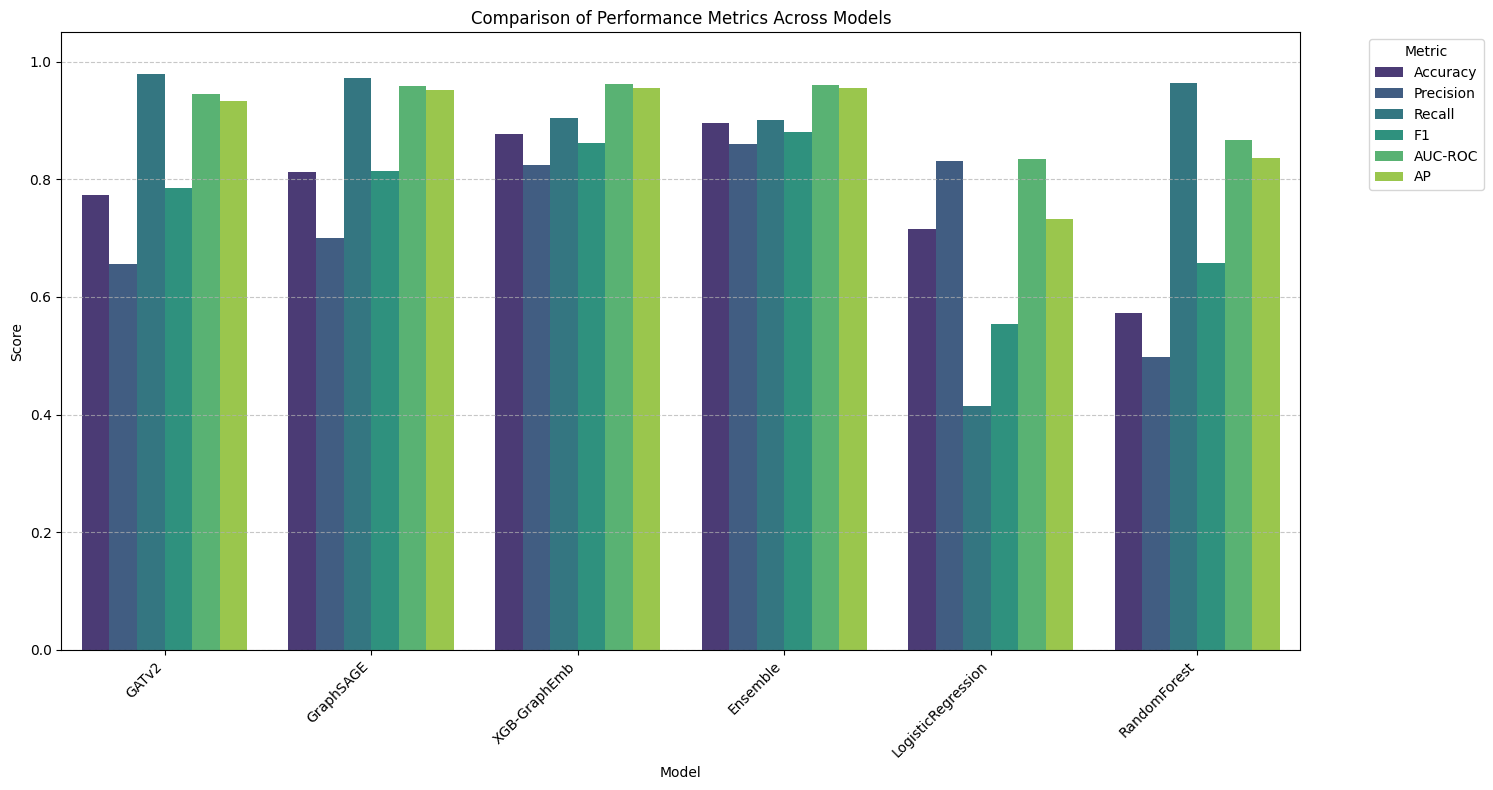

Bar chart comparing all metrics saved as all_metrics_bar_chart.png


In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, roc_curve

plot_data_list = []
labels = test_graph.y.numpy()

y_xgb_test_labels = y_emb_test if 'XGB-GraphEmb' in results else labels

for name, r in results.items():
    if name == 'Ensemble':
        ensemble_probs = (0.35 * results['GATv2']['probs'] +
                          0.30 * results['XGB-GraphEmb']['probs'][:, 1]) # Select positive class probabilities
        fpr_, tpr_, thresholds_ = roc_curve(labels, ensemble_probs)
        best_thresh = thresholds_[np.argmax(tpr_ - fpr_)]
        ensemble_preds = (ensemble_probs >= best_thresh).astype(int)

        e_acc   = accuracy_score(labels, ensemble_preds)
        e_prec  = precision_score(labels, ensemble_preds, zero_division=0)
        e_rec   = recall_score(labels, ensemble_preds, zero_division=0)
        e_f1    = f1_score(labels, ensemble_preds)
        e_auc   = roc_auc_score(labels, ensemble_probs)
        e_ap    = average_precision_score(labels, ensemble_probs)

        plot_data_list.append({
            'Model': name,
            'Accuracy': e_acc,
            'Precision': e_prec,
            'Recall': e_rec,
            'F1': e_f1,
            'AUC-ROC': e_auc,
            'AP': e_ap
        })
    elif 'preds' in r and 'probs' in r:
        current_labels = y_xgb_test_labels if name == 'XGB-GraphEmb' else labels
        acc = accuracy_score(current_labels, r['preds'])
        plot_data_list.append({
            'Model': name,
            'Accuracy': acc,
            'Precision': r['Precision'],
            'Recall': r['Recall'],
            'F1': r['F1'],
            'AUC-ROC': r['AUC'],
            'AP': r['AP']
        })

metrics_df = pd.DataFrame(plot_data_list)
metrics_df_melted = metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(15, 8))
sns.barplot(x='Model', y='Score', hue='Metric', data=metrics_df_melted, palette='viridis')
plt.title('Comparison of Performance Metrics Across Models')
plt.xlabel('Model')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('all_metrics_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print("Bar chart comparing all metrics saved as all_metrics_bar_chart.png")

# Full Visualizations

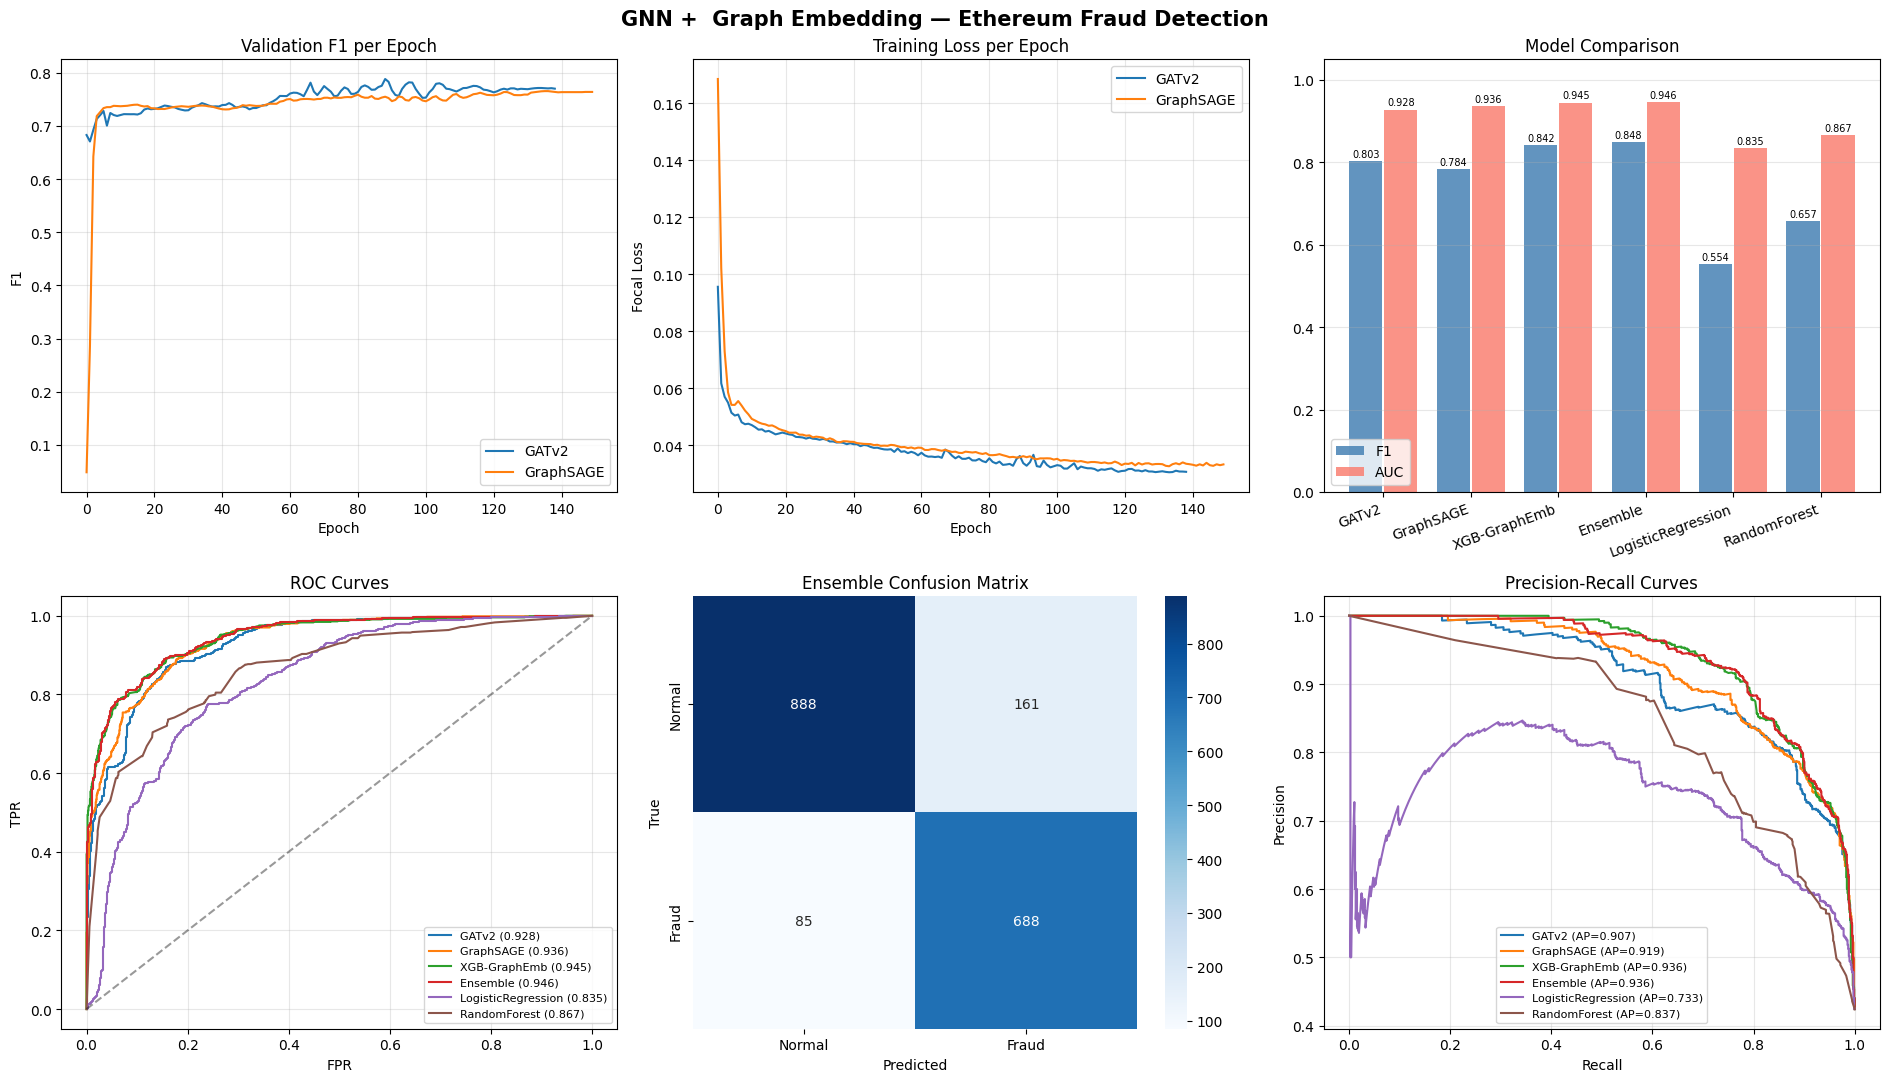

Plots saved as fraud_results.png


In [28]:
fig, axes = plt.subplots(2, 3, figsize=(19, 11))
fig.suptitle("GNN +  Graph Embedding — Ethereum Fraud Detection",
             fontsize=15, fontweight='bold')


ax = axes[0, 0]
for name, hist in [('GATv2', gat_hist), ('GraphSAGE', sage_hist)]:
    ax.plot(hist['val_f1'], label=name)
ax.set(title='Validation F1 per Epoch', xlabel='Epoch', ylabel='F1'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[0, 1]
for name, hist in [('GATv2', gat_hist), ('GraphSAGE', sage_hist)]:
    ax.plot(hist['loss'], label=name)
ax.set(title='Training Loss per Epoch', xlabel='Epoch', ylabel='Focal Loss'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[0, 2]
mnames = list(results.keys())
x = np.arange(len(mnames))
b1 = ax.bar(x - 0.2, [results[m]['F1']  for m in mnames], 0.38, label='F1',  color='steelblue', alpha=0.85)
b2 = ax.bar(x + 0.2, [results[m]['AUC'] for m in mnames], 0.38, label='AUC', color='salmon',    alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(mnames, rotation=20, ha='right')
ax.set(title='Model Comparison', ylim=(0, 1.05)); ax.legend(loc='lower left'); ax.grid(alpha=0.3, axis='y')
for b in list(b1) + list(b2):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
            f"{b.get_height():.3f}", ha='center', fontsize=7)

ax = axes[1, 0]
plot_data = [('GATv2',       results['GATv2']['probs'],       labels),
             ('GraphSAGE',   results['GraphSAGE']['probs'],   labels),
             ('XGB-GraphEmb',results['XGB-GraphEmb']['probs'][:, 1],y_emb_test),
             ('Ensemble',    ensemble_probs,                  labels),
             ('LogisticRegression', results['LogisticRegression']['probs'], labels),
             ('RandomForest',       results['RandomForest']['probs'],       labels)]
for (n, probs, lbl) in plot_data:
    fp, tp, _ = roc_curve(lbl, probs)
    ax.plot(fp, tp, label=f"{n} ({roc_auc_score(lbl,probs):.3f})")
ax.plot([0,1],[0,1],'k--', alpha=0.4)
ax.set(title='ROC Curves', xlabel='FPR', ylabel='TPR'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1, 1]
cm = confusion_matrix(labels, ensemble_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Normal','Fraud'], yticklabels=['Normal','Fraud'])
ax.set(title='Ensemble Confusion Matrix', ylabel='True', xlabel='Predicted')

ax = axes[1, 2]
for (n, probs, lbl) in plot_data:
    prec, rec, _ = precision_recall_curve(lbl, probs)
    ap_ = average_precision_score(lbl, probs)
    ax.plot(rec, prec, label=f"{n} (AP={ap_:.3f})")
ax.set(title='Precision-Recall Curves', xlabel='Recall', ylabel='Precision')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fraud_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plots saved as fraud_results.png")

Running t-SNE on GATv2 node embeddings ...


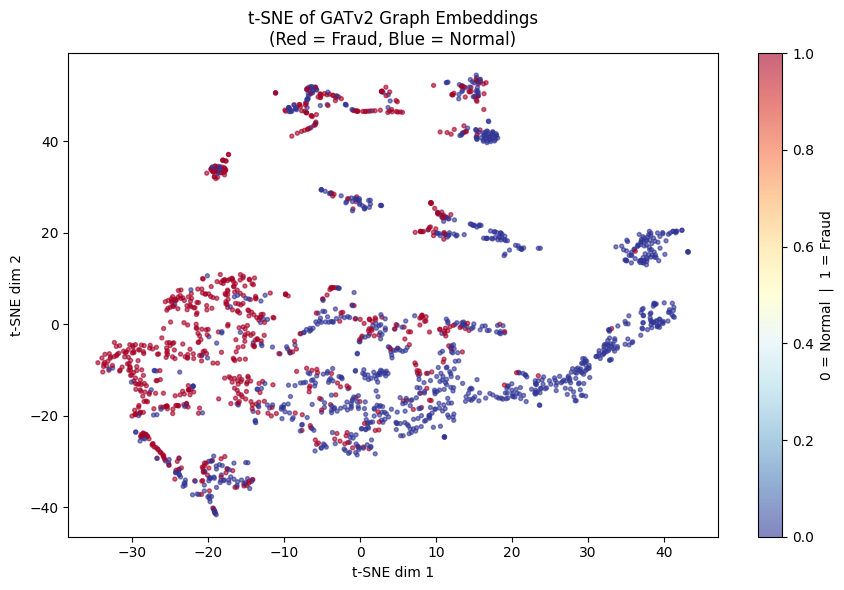

t-SNE saved as tsne_embeddings.png


In [29]:
print("Running t-SNE on GATv2 node embeddings ...")
sample_n = min(2000, len(labels))
tsne   = TSNE(n_components=2, perplexity=40, n_iter=1000, random_state=42)
emb_2d = tsne.fit_transform(node_embeddings['GATv2'][:sample_n])
lbl_2d = labels[:sample_n]

plt.figure(figsize=(9, 6))
sc = plt.scatter(emb_2d[:, 0], emb_2d[:, 1], c=lbl_2d,
                 cmap='RdYlBu_r', alpha=0.6, s=8)
plt.colorbar(sc, label='0 = Normal  |  1 = Fraud')
plt.title("t-SNE of GATv2 Graph Embeddings\n(Red = Fraud, Blue = Normal)")
plt.xlabel("t-SNE dim 1"); plt.ylabel("t-SNE dim 2")
plt.tight_layout()
plt.savefig('tsne_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()
print("t-SNE saved as tsne_embeddings.png")


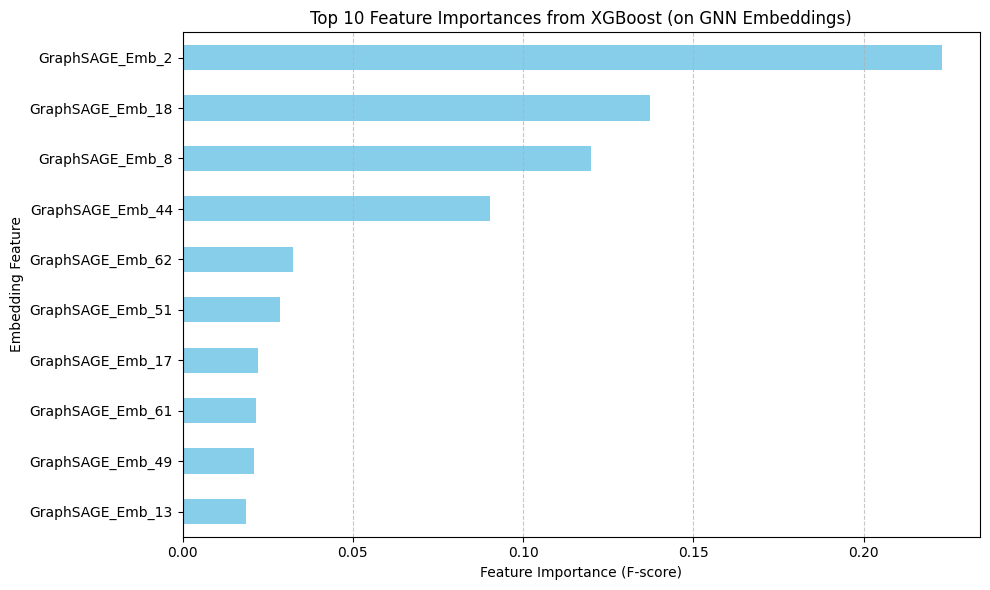

Top 10 Feature Importances for XGBoost:
GraphSAGE_Emb_2     0.222982
GraphSAGE_Emb_18    0.137317
GraphSAGE_Emb_8     0.119768
GraphSAGE_Emb_44    0.090201
GraphSAGE_Emb_62    0.032276
GraphSAGE_Emb_51    0.028641
GraphSAGE_Emb_17    0.022080
GraphSAGE_Emb_61    0.021532
GraphSAGE_Emb_49    0.021051
GraphSAGE_Emb_13    0.018744
dtype: float32
Plot saved as xgb_feature_importance.png


In [30]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

xgb_importances = xgb_model.feature_importances_

gatv2_emb_dim = gat_model(train_graph.x.to(device), train_graph.edge_index.to(device))[1].shape[1]
sage_emb_dim  = sage_model(train_graph.x.to(device), train_graph.edge_index.to(device))[1].shape[1]

feature_labels = [f'GATv2_Emb_{i}' for i in range(gatv2_emb_dim)] + \
                 [f'GraphSAGE_Emb_{i}' for i in range(sage_emb_dim)]

importance_series = pd.Series(xgb_importances, index=feature_labels)

top_10_features = importance_series.nlargest(10)

fig = plt.figure(figsize=(10, 6))
top_10_features.sort_values(ascending=True).plot(kind='barh', color='skyblue')
plt.title('Top 10 Feature Importances from XGBoost (on GNN Embeddings)')
plt.xlabel('Feature Importance (F-score)')
plt.ylabel('Embedding Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 Feature Importances for XGBoost:")
print(top_10_features)
print("Plot saved as xgb_feature_importance.png")

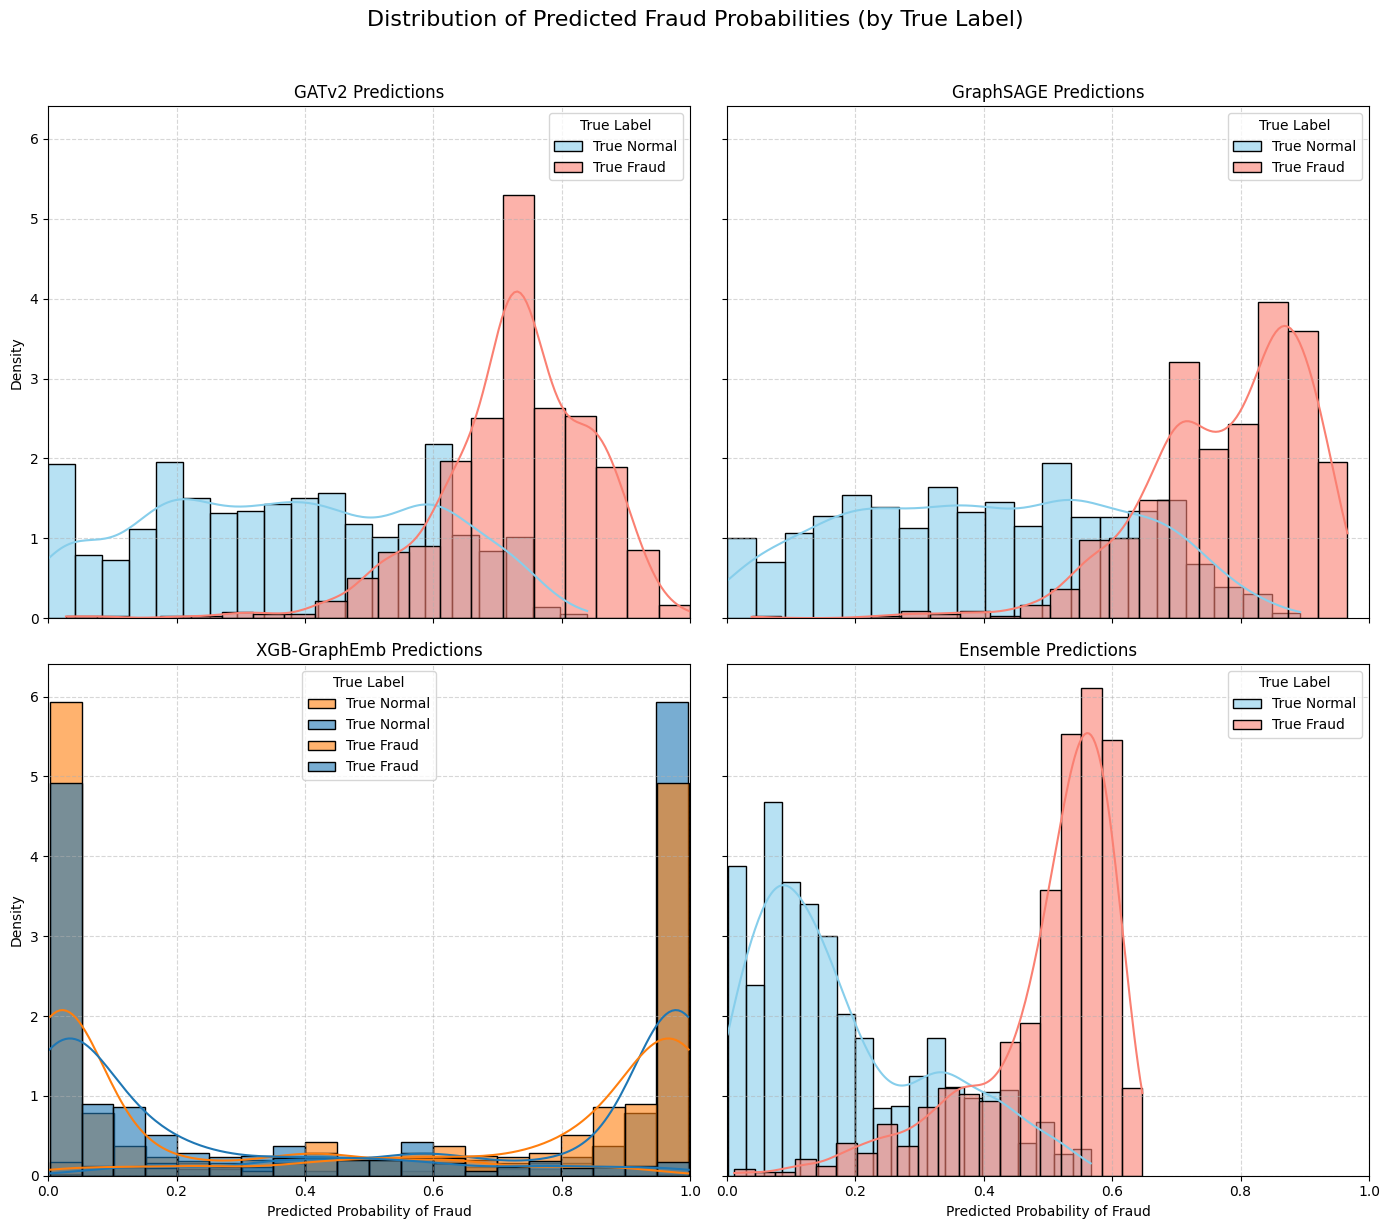

Prediction distribution plots saved as prediction_distribution.png


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

labels = test_graph.y.cpu().numpy()

fig, axes = plt.subplots(2, 2, figsize=(14, 12), sharex=True, sharey=True)
fig.suptitle('Distribution of Predicted Fraud Probabilities (by True Label)', fontsize=16, y=1.02)

plot_data_list = [
    ('GATv2',       results['GATv2']['probs'],       labels),
    ('GraphSAGE',   results['GraphSAGE']['probs'],   labels),
    ('XGB-GraphEmb',results['XGB-GraphEmb']['probs'],y_emb_test),
    ('Ensemble',    ensemble_probs,                  labels)
]

for i, (name, probs, true_labels) in enumerate(plot_data_list):
    row = i // 2
    col = i % 2
    ax = axes[row, col]

    normal_probs = probs[true_labels == 0]
    fraud_probs  = probs[true_labels == 1]

    sns.histplot(normal_probs, color='skyblue', label='True Normal', kde=True, ax=ax, stat='density', alpha=0.6, bins=20)
    sns.histplot(fraud_probs,  color='salmon',  label='True Fraud',  kde=True, ax=ax, stat='density', alpha=0.6, bins=20)

    ax.set_title(f'{name} Predictions')
    ax.set_xlabel('Predicted Probability of Fraud')
    ax.set_ylabel('Density')
    ax.legend(title='True Label')
    ax.set_xlim(0, 1)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('prediction_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Prediction distribution plots saved as prediction_distribution.png")

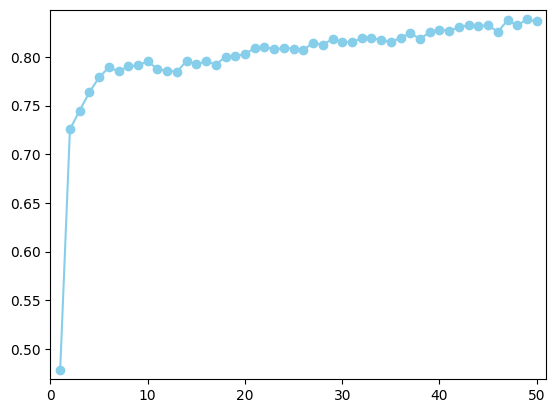

Epoch 50, Loss: 0.3497, Accuracy: 0.8365


In [32]:
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

accuracies = []
epochs_to_train = 50


in_ch = X_train_res.shape[1]
model = GATv2Fraud(in_ch).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-3, weight_decay=1e-4)
data = train_graph.to(device)


plt.figure(figsize=(6, 4))
plt.title('Model Live Training Convergence (Accuracy vs. Epoch)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.6)

for epoch in range(epochs_to_train):
    model.train()
    optimizer.zero_grad()

    out, _ = model(data.x, data.edge_index)

    loss = F.cross_entropy(out, data.y.long())

    loss.backward()
    optimizer.step()


    pred = out.argmax(dim=1)
    correct = (pred == data.y).sum().item()
    acc = correct / data.y.size(0)

    accuracies.append(acc)


    clear_output(wait=True)
    plt.plot(range(1, len(accuracies) + 1), accuracies, marker='o', linestyle='-', color='skyblue')
    plt.xlim(0, epochs_to_train + 1)
    plt.ylim(min(accuracies) - 0.01 if accuracies else 0, max(accuracies) + 0.01 if accuracies else 1)
    plt.show()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}, Accuracy: {acc:.4f}")